# HR Employee Attrition  

**Goal:** Investigate the five exam questions using clear, intermediate-level Python.

This notebook goes beyond simple counts by using:
- attrition percentages
- group comparisons
- average differences
- sorted tables
- simple visualizations
- a few useful derived columns
- short evidence-based conclusions

**Important:** These are patterns/associations in the dataset. They do not prove that a variable directly causes attrition.


## 1. Import Libraries and Load Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Basic Data Investigation

In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nAttrition counts:")
print(df["Attrition"].value_counts())

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
Environme

In [ ]:
# Overall attrition percentage

attrition_percent = df["Attrition"].value_counts(normalize=True) * 100
print(attrition_percent.round(2))

print("Overall Attrition Rate:",
      round((df["Attrition"] == "Yes").mean() * 100, 2), "%")

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64
Overall Attrition Rate: 16.12 %


# EDA Report

In [43]:
# !pip install ydata-profiling
import ydata_profiling as yd

report = yd.ProfileReport(df)
report.to_file("report.html")
yd.ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 39/39 [00:00<00:00, 47.42it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 39/39 [00:00<00:00, 41.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Q1 Where Is the Attrition Problem?

We investigate **Department, JobRole and OverTime**.

Instead of only looking at counts, we calculate the percentage of employees who left inside each group. This is a fairer comparison because the groups have different numbers of employees.


In [ ]:
# Department analysis

department = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department = department.round(2)
print(department)

Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


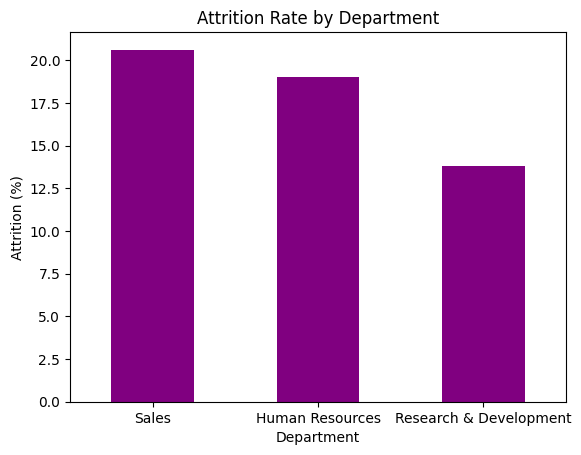

In [ ]:
# Department attrition rate

department["Yes"].sort_values(ascending=False).plot(kind="bar",color="purple")
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# OverTime analysis

overtime = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

print(overtime.round(2))

Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


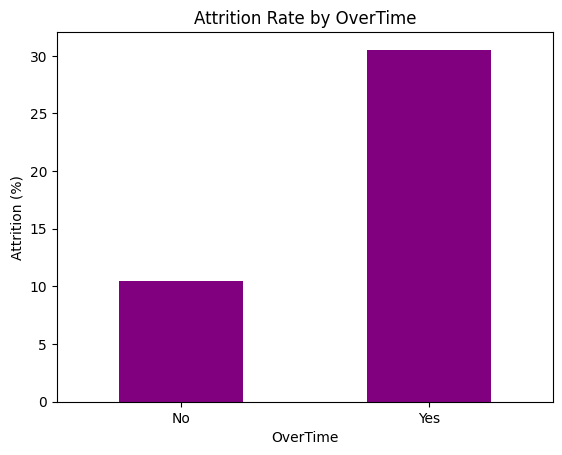

In [ ]:
overtime["Yes"].plot(kind="bar",color="purple")
plt.title("Attrition Rate by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Attrition (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Job role analysis

role = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

role = role.sort_values("Yes", ascending=False)
print(role.round(2))

Attrition                     No    Yes
JobRole                                
Sales Representative       60.24  39.76
Laboratory Technician      76.06  23.94
Human Resources            76.92  23.08
Sales Executive            82.52  17.48
Research Scientist         83.90  16.10
Manufacturing Director     93.10   6.90
Healthcare Representative  93.13   6.87
Manager                    95.10   4.90
Research Director          97.50   2.50


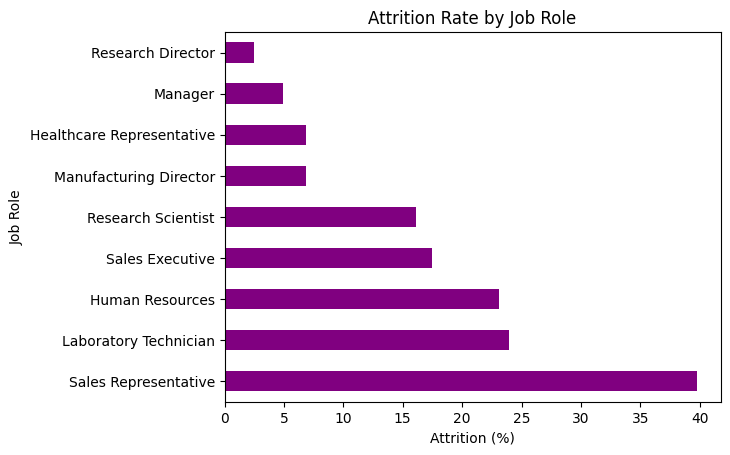

In [ ]:
role["Yes"].plot(kind="barh",color="purple")
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition (%)")
plt.ylabel("Job Role")
plt.show()

In [ ]:
# Simple comparison table for Q1

q1_summary = pd.DataFrame({
    "Department Attrition": department["Yes"],
    "OverTime Attrition": overtime["Yes"]
})

print("Job role with highest attrition:")
print(role["Yes"].head(3).round(2))

print("\nDepartment attrition range:",
      round(department["Yes"].max() - department["Yes"].min(), 2),
      "percentage points")

print("OverTime attrition difference:",
      round(overtime["Yes"].max() - overtime["Yes"].min(), 2),
      "percentage points")

Job role with highest attrition:
JobRole
Sales Representative     39.76
Laboratory Technician    23.94
Human Resources          23.08
Name: Yes, dtype: float64

Department attrition range: 6.79 percentage points
OverTime attrition difference: 20.09 percentage points


### Q1 Investigation Insight

The key point is not simply which group has the most employees leaving. We compare **rates within groups**.

A strong report should mention:
1. whether departments have similar or different attrition rates;
2. the difference between employees with and without overtime;
3. the job roles with the highest observed attrition;
4. which comparison shows the clearest difference.

This tells HR where to investigate first without claiming that the group itself causes attrition.


# Q2  Are Employees Leaving Because of Their Work Experience?

We investigate:
- JobSatisfaction
- EnvironmentSatisfaction
- JobInvolvement
- WorkLifeBalance

For each variable, we compare attrition rates across rating levels.


In [ ]:
experience_cols = [
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "WorkLifeBalance"
]

for col in experience_cols:
    print("\n", col)
    print(df[col].value_counts().sort_index())


 JobSatisfaction
JobSatisfaction
1    289
2    280
3    442
4    459
Name: count, dtype: int64

 EnvironmentSatisfaction
EnvironmentSatisfaction
1    284
2    287
3    453
4    446
Name: count, dtype: int64

 JobInvolvement
JobInvolvement
1     83
2    375
3    868
4    144
Name: count, dtype: int64

 WorkLifeBalance
WorkLifeBalance
1     80
2    344
3    893
4    153
Name: count, dtype: int64


In [ ]:
# Create one table containing attrition rates for all four variables

experience_results = []

for col in experience_cols:
    rates = df.groupby(col)["Attrition"].apply(
        lambda x: (x == "Yes").mean() * 100
    )

    for rating, rate in rates.items():
        experience_results.append([col, rating, rate])

experience_table = pd.DataFrame(
    experience_results,
    columns=["Variable", "Rating", "AttritionRate"]
)

experience_table["AttritionRate"] = experience_table["AttritionRate"].round(2)

experience_table

,Variable,Rating,AttritionRate
0,JobSatisfaction,1,22.84
1,JobSatisfaction,2,16.43
2,JobSatisfaction,3,16.52
3,JobSatisfaction,4,11.33
4,EnvironmentSatisfaction,1,25.35
5,EnvironmentSatisfaction,2,14.98
6,EnvironmentSatisfaction,3,13.69
7,EnvironmentSatisfaction,4,13.45
8,JobInvolvement,1,33.73
9,JobInvolvement,2,18.93


In [ ]:
# Find the range of attrition inside each experience variable

experience_summary = (
    experience_table.groupby("Variable")["AttritionRate"]
    .agg(["min", "max"])
)

experience_summary["Difference"] = (
    experience_summary["max"] - experience_summary["min"]
)

experience_summary = experience_summary.sort_values(
    "Difference", ascending=False
).round(2)

experience_summary

,min,max,Difference
Variable,,,
JobInvolvement,9.03,33.73,24.70
WorkLifeBalance,14.22,31.25,17.03
EnvironmentSatisfaction,13.45,25.35,11.90
JobSatisfaction,11.33,22.84,11.51


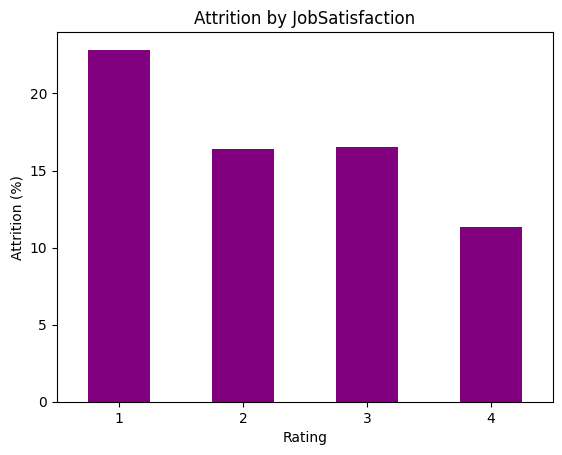

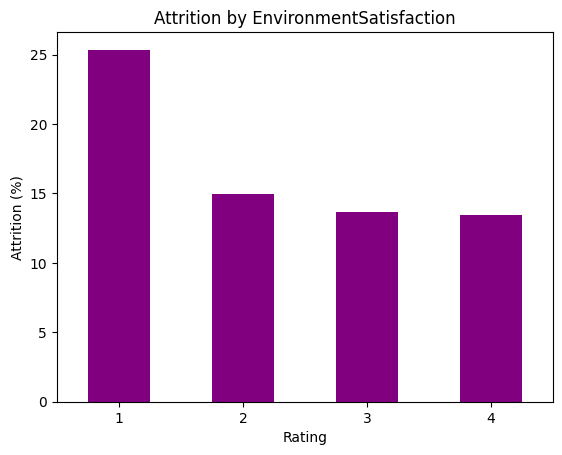

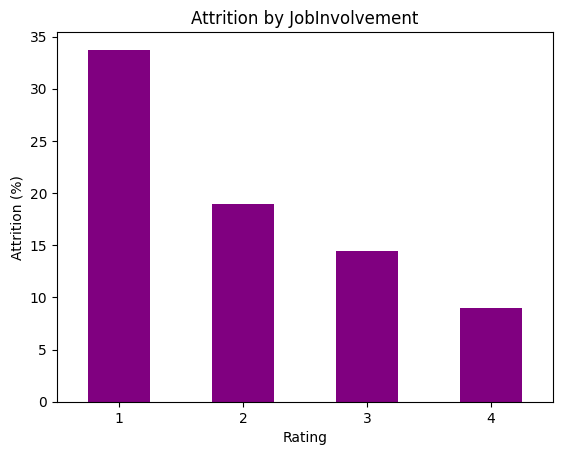

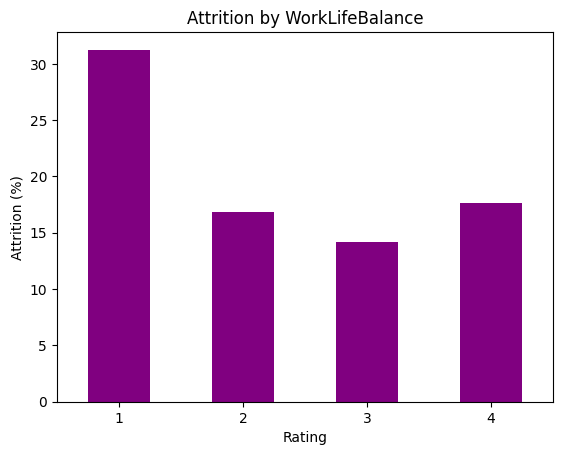

In [ ]:
# Plot the four experience variables

for col in experience_cols:
    rates = df.groupby(col)["Attrition"].apply(
        lambda x: (x == "Yes").mean() * 100
    )

    rates.plot(kind="bar",color="purple")
    plt.title("Attrition by " + col)
    plt.xlabel("Rating")
    plt.ylabel("Attrition (%)")
    plt.xticks(rotation=0)
    plt.show()

In [ ]:
# Compare low and high ratings

low_high = []

for col in experience_cols:
    rates = df.groupby(col)["Attrition"].apply(
        lambda x: (x == "Yes").mean() * 100
    )

    low_rating = rates.index.min()
    high_rating = rates.index.max()

    low_high.append([
        col,
        rates.loc[low_rating],
        rates.loc[high_rating],
        rates.loc[low_rating] - rates.loc[high_rating]
    ])

low_high_table = pd.DataFrame(
    low_high,
    columns=["Variable", "Lowest Rating Attrition",
             "Highest Rating Attrition", "Difference"]
)

low_high_table.round(2)

,Variable,Lowest Rating Attrition,Highest Rating Attrition,Difference
0,JobSatisfaction,22.84,11.33,11.51
1,EnvironmentSatisfaction,25.35,13.45,11.90
2,JobInvolvement,33.73,9.03,24.71
3,WorkLifeBalance,31.25,17.65,13.60


### Q2 Investigation Insight

The `experience_summary` table gives a useful way to decide which workplace-experience variable has the clearest pattern.

The variable with the largest `Difference` has the largest spread in observed attrition across its rating levels.

This is a **reason for further HR investigation**, not evidence that the variable directly causes employees to leave.


# Q3 Who Is Leaving the Organization?

We compare employees who stayed and employees who left using:
- Age
- MonthlyIncome
- TotalWorkingYears
- YearsAtCompany
- YearsInCurrentRole

We will use both **group averages** and **boxplots**.


In [ ]:
q3_cols = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole"
]

q3_means = df.groupby("Attrition")[q3_cols].mean().round(2)
q3_means

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole
Attrition,,,,,
No,37.56,6832.74,11.86,7.37,4.48
Yes,33.61,4787.09,8.24,5.13,2.90


In [ ]:
# Difference between leavers and stayers

q3_difference = q3_means.loc["Yes"] - q3_means.loc["No"]

q3_comparison = pd.DataFrame({
    "Stayed Average": q3_means.loc["No"],
    "Left Average": q3_means.loc["Yes"],
    "Difference (Left - Stayed)": q3_difference
}).round(2)

q3_comparison

,Stayed Average,Left Average,Difference (Left - Stayed)
Age,37.56,33.61,-3.95
MonthlyIncome,6832.74,4787.09,-2045.65
TotalWorkingYears,11.86,8.24,-3.62
YearsAtCompany,7.37,5.13,-2.24
YearsInCurrentRole,4.48,2.90,-1.58


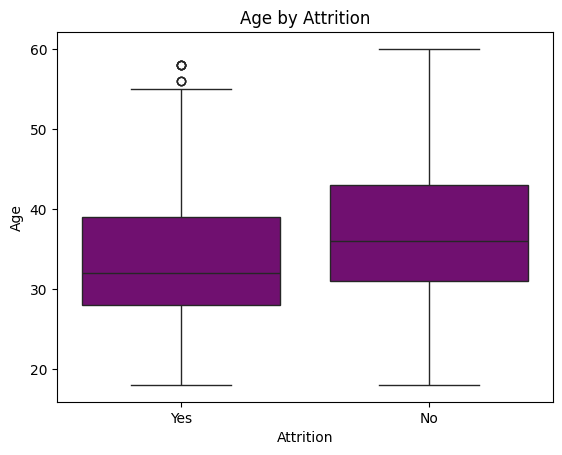

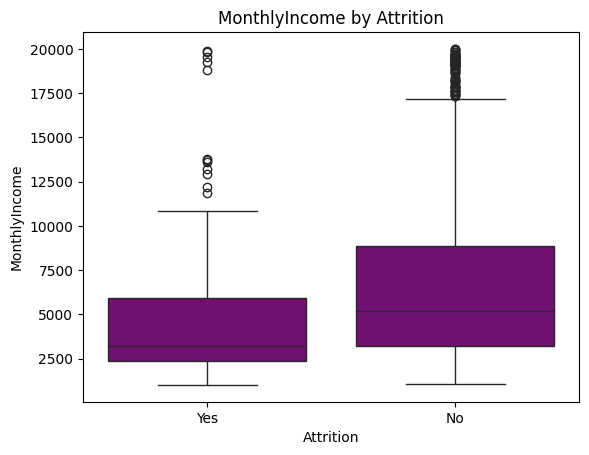

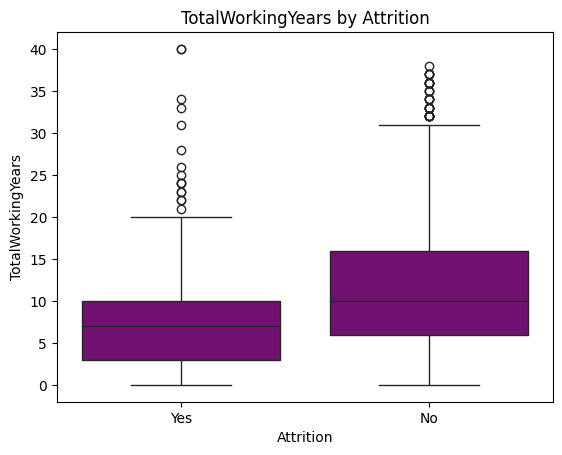

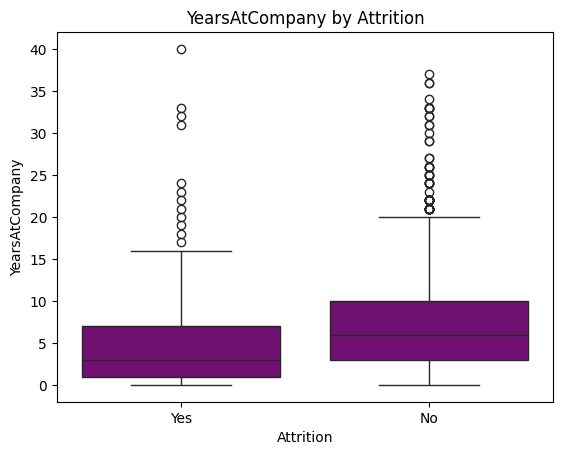

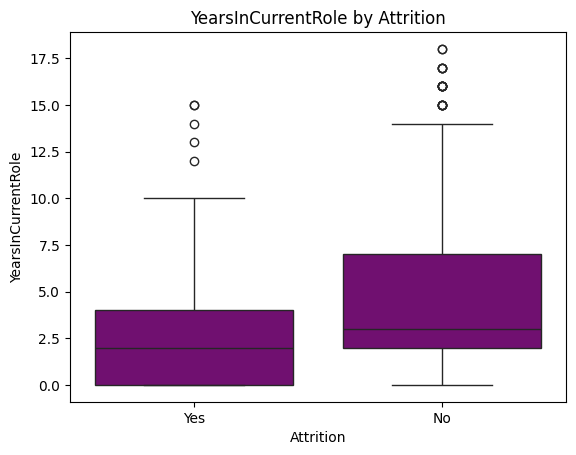

In [ ]:
# Boxplots

for col in q3_cols:
    sns.boxplot(data=df, x="Attrition", y=col,color="purple")
    plt.title(col + " by Attrition")
    plt.xlabel("Attrition")
    plt.ylabel(col)
    plt.show()

In [ ]:
# A simple additional comparison:
# percentage of employees with less than 3 years at the company

df["ShortTenure"] = df["YearsAtCompany"] < 3

short_tenure = pd.crosstab(
    df["ShortTenure"],
    df["Attrition"],
    normalize="index"
) * 100

short_tenure.round(2)

Attrition,No,Yes
ShortTenure,,
False,88.03,11.97
True,70.18,29.82


### Q3 Investigation Insight

The averages show the general profile of employees who stayed versus employees who left.

The boxplots add another view because they show the spread of the data rather than only one average.

The `ShortTenure` comparison is an additional simple investigation. If the attrition rate for employees with less than three years at the company is noticeably different, HR can investigate early-tenure retention separately.


# Q4 Create a Career Stage

We will create a CareerStage variable using TotalWorkingYears.

Categories:
- 0–2 years: Entry
- 3–7 years: Early Career
- 8–15 years: Established
- 16+ years: Senior

This converts a numeric experience variable into simple HR-friendly groups.


In [ ]:
def career_stage(years):
    if years <= 2:
        return "Entry"
    elif years <= 7:
        return "Early Career"
    elif years <= 15:
        return "Established"
    else:
        return "Senior"

df["CareerStage"] = df["TotalWorkingYears"].apply(career_stage)

print(df["CareerStage"].value_counts())

CareerStage
Established     592
Early Career    399
Senior          356
Entry           123
Name: count, dtype: int64


In [ ]:
career_attrition = pd.crosstab(
    df["CareerStage"],
    df["Attrition"],
    normalize="index"
) * 100

career_attrition = career_attrition.round(2)
career_attrition

Attrition,No,Yes
CareerStage,,
Early Career,80.70,19.30
Entry,56.10,43.90
Established,87.33,12.67
Senior,91.29,8.71


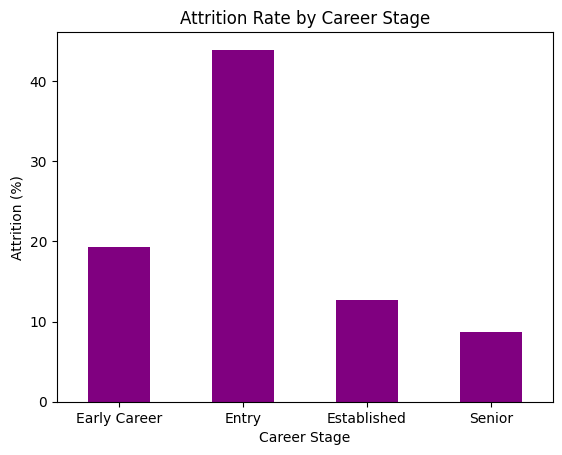

In [ ]:
career_attrition["Yes"].plot(kind="bar",color="purple")
plt.title("Attrition Rate by Career Stage")
plt.xlabel("Career Stage")
plt.ylabel("Attrition (%)")
plt.xticks(rotation=0)
plt.show()

### Q4 Investigation Insight

CareerStage is useful because HR can compare employees by a broad career position instead of looking only at individual years.

If one stage has a noticeably higher attrition rate, that stage can be investigated through onboarding, career development, promotion opportunities, workload, or employee feedback.


# Q5 Build an Employee Experience Indicator

The exam asks for an indicator using at least three experience variables.

We will use all four:
- JobSatisfaction
- EnvironmentSatisfaction
- JobInvolvement
- WorkLifeBalance

The score is their simple average.


In [ ]:
df["EmployeeExperienceScore"] = df[experience_cols].mean(axis=1)

df[
    experience_cols + ["EmployeeExperienceScore"]
].head()

,JobSatisfaction,EnvironmentSatisfaction,JobInvolvement,WorkLifeBalance,EmployeeExperienceScore
0,4,2,3,1,2.50
1,2,3,2,3,2.50
2,3,4,2,3,3.00
3,3,4,3,3,3.25
4,2,1,3,3,2.25


In [ ]:
# Create three easy-to-understand groups

def experience_group(score):
    if score < 2:
        return "Low"
    elif score < 3:
        return "Medium"
    else:
        return "High"

df["ExperienceGroup"] = df["EmployeeExperienceScore"].apply(experience_group)

print(df["ExperienceGroup"].value_counts())

ExperienceGroup
Medium    851
High      570
Low        49
Name: count, dtype: int64


In [ ]:
experience_attrition = pd.crosstab(
    df["ExperienceGroup"],
    df["Attrition"],
    normalize="index"
) * 100

experience_attrition = experience_attrition.round(2)
experience_attrition

Attrition,No,Yes
ExperienceGroup,,
High,89.82,10.18
Low,55.10,44.90
Medium,81.55,18.45


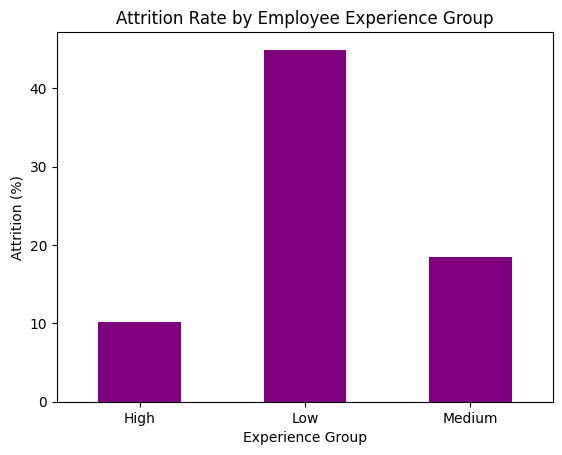

In [ ]:
experience_attrition["Yes"].plot(kind="bar",color="purple")
plt.title("Attrition Rate by Employee Experience Group")
plt.xlabel("Experience Group")
plt.ylabel("Attrition (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Compare the average score of employees who stayed and left

score_comparison = df.groupby("Attrition")["EmployeeExperienceScore"].mean()

print(score_comparison.round(2))

print("\nDifference in average experience score:")
print(round(score_comparison["No"] - score_comparison["Yes"], 2))

Attrition
No     2.78
Yes    2.53
Name: EmployeeExperienceScore, dtype: float64

Difference in average experience score:
0.25


In [ ]:
# Look at the four components alongside the combined score

experience_means = df.groupby("Attrition")[
    experience_cols + ["EmployeeExperienceScore"]
].mean().round(2)

experience_means

,JobSatisfaction,EnvironmentSatisfaction,JobInvolvement,WorkLifeBalance,EmployeeExperienceScore
Attrition,,,,,
No,2.78,2.77,2.77,2.78,2.78
Yes,2.47,2.46,2.52,2.66,2.53


### Q5 Investigation Insight

The combined score gives HR a single summary of workplace experience.

The final table is especially useful because it shows whether the overall score difference is supported by the individual experience measures.

If employees who left have a lower average experience score, this indicates an observed association worth investigating further. It should not be described as proof that the score causes attrition.


# Final Investigation Summary

## What the analysis should communicate

### Q1  Attrition location
Use Department, JobRole and OverTime attrition rates to identify groups with noticeable differences.

### Q2  Workplace experience
Compare the four experience variables and use the difference between their rating groups to identify which variable shows the clearest pattern.

### Q3  Employee profile
Compare the averages and distributions of Age, MonthlyIncome, TotalWorkingYears, YearsAtCompany and YearsInCurrentRole.

### Q4  Career stage
Use the engineered CareerStage variable to see whether attrition changes across career stages.

### Q5  Overall experience
Use EmployeeExperienceScore to summarize several workplace-experience measures and compare it with Attrition.

## Final limitation

The analysis identifies patterns and associations in this dataset. It does not establish direct cause and effect. HR should use these findings to decide which employee groups and workplace factors need deeper investigation.
